In [ ]:
# Exploratory Analysis on Entire Dataset
# Fit Model on Training Dataset (Balanced)
# Evaluate Model on Test Dataset (Balanced)

In [2]:
import pandas as pd

In [3]:
df = pd.read_csv("heart_disease_health_indicators_BRFSS2015.csv")
df = df.astype("int32")
df

,HeartDiseaseorAttack,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,Diabetes,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0,1,1,1,40,1,0,0,0,0,...,1,0,5,18,15,1,0,9,4,3
1,0,0,0,0,25,1,0,0,1,0,...,0,1,3,0,0,0,0,7,6,1
2,0,1,1,1,28,0,0,0,0,1,...,1,1,5,30,30,1,0,9,4,8
3,0,1,0,1,27,0,0,0,1,1,...,1,0,2,0,0,0,0,11,3,6
4,0,1,1,1,24,0,0,0,1,1,...,1,0,2,3,0,0,0,11,5,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
253675,0,1,1,1,45,0,0,0,0,1,...,1,0,3,0,5,0,1,5,6,7
253676,0,1,1,1,18,0,0,2,0,0,...,1,0,4,0,0,1,0,11,2,4
253677,0,0,0,1,28,0,0,0,1,1,...,1,0,1,0,0,0,0,2,5,2
253678,0,1,0,1,23,0,0,0,0,1,...,1,0,3,0,0,0,1,7,5,1


In [4]:
# OG BMI
OG_BMI = df["BMI"]
# Relabel BMI based on CDC
    # 0 - Underweight
    # 1 - Healthy
    # 2 - Overweight
    # 3 - Obese
BMI_cat = []
for i in df["BMI"]:
    if i <= 19:
        BMI_cat.append(0)
    elif (i > 19) & (i < 25):
        BMI_cat.append(1)
    elif (i >= 25) & (i < 30):
        BMI_cat.append(2)
    else:
        BMI_cat.append(3)
df["BMI_cat"] = BMI_cat
# OG PhysHlth
OG_PhysHlth = df["PhysHlth"]
# Relabel PhysHlth
    # 0 - 0 days
    # 1 - At most 1 week
    # 2 - 1-2 weeks
    # 3 - 2-3 weeks
    # 4 - 3 weeks - 1 month
PhysHlth_cat = []
for i in df["PhysHlth"]:
    if i == 0:
        PhysHlth_cat.append(0)
    elif (i > 0) & (i <= 7):
        PhysHlth_cat.append(1)
    elif (i > 7) & (i <= 14):
        PhysHlth_cat.append(2)
    elif (i > 14) & (i <= 21):
        PhysHlth_cat.append(3)
    else:
        PhysHlth_cat.append(4)
df["PhysHlth_cat"] = PhysHlth_cat
# OG MentHlth
OG_MentHlth = df["MentHlth"]
# Relabel MentHlth
    # 0 - 0 days
    # 1 - At most 1 week
    # 2 - 1-2 weeks
    # 3 - 2-3 weeks
    # 4 - 3 weeks - 1 month
MentHlth_cat = []
for i in df["MentHlth"]:
    if i == 0:
        MentHlth_cat.append(0)
    elif (i > 0) & (i <= 7):
        MentHlth_cat.append(1)
    elif (i > 7) & (i <= 14):
        MentHlth_cat.append(2)
    elif (i > 14) & (i <= 21):
        MentHlth_cat.append(3)
    else:
        MentHlth_cat.append(4)
df["MentHlth_cat"] = MentHlth_cat
df = df.drop(columns=["BMI","PhysHlth","MentHlth"])

In [75]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

In [5]:
import numpy as np
import plotnine as p9
from concurrent.futures import ThreadPoolExecutor

In [6]:
def CE(df,B,df_xs=None,df_ys=None,distr=False):
    N = df.shape[0]
    # CE(Y)
    if type(df_xs) == type(None):
        ys_names = [col.name for col in df_ys]
        prob_Y = df[ys_names].value_counts()/N
        def CE_Y(b):
            rng = np.random.RandomState(b)
            new_freq_Y = rng.multinomial(N,prob_Y)
            new_prob_Y = new_freq_Y/N
            new_CE_Y = -np.log(new_prob_Y[new_prob_Y!=0]).T@new_prob_Y[new_prob_Y!=0]
            return new_CE_Y
        if __name__ == '__main__':
            with ThreadPoolExecutor() as executor:
                B_num_CE_Y = list(executor.map(CE_Y, range(B)))
        if distr == False:
            return np.array(B_num_CE_Y)
        else:
            B_num_CE_Y_df = pd.DataFrame({"CE_Y":B_num_CE_Y})
            B_num_plot = (
            p9.ggplot(B_num_CE_Y_df)+
                p9.geom_density(p9.aes(x="CE_Y"))
            )
            print(B_num_plot)
    # CE(Y|X)
    else:
        con_table = pd.crosstab(df_xs,df_ys,margins = True)
        prob_table = (con_table.T/con_table["All"]).T.iloc[:-1,:-1]
        prob_X_i = con_table.iloc[:-1,:]["All"]/N
        def CE_Y_X(b):
            rng = np.random.RandomState(b)
            new_n_X = rng.multinomial(N,prob_X_i)
            new_CE_Y_X_i = []
            for i in range(prob_table.shape[0]):
                prob_Y_X_i = prob_table.iloc[i,:]
                if new_n_X[i] != 0:
                    new_prob_Y_X_i = rng.multinomial(new_n_X[i],prob_Y_X_i)/new_n_X[i]
                    new_CE_Y_X_i.append(-np.log(new_prob_Y_X_i[new_prob_Y_X_i!=0]).T@new_prob_Y_X_i[new_prob_Y_X_i!=0])
                else:
                    new_CE_Y_X_i.append(0)
            new_prob_X = new_n_X/N
            new_CE_Y_X = new_prob_X.T@new_CE_Y_X_i
            return new_CE_Y_X
        if __name__ == '__main__':
            with ThreadPoolExecutor() as executor:
                B_num_CE_Y_X = list(executor.map(CE_Y_X, range(B)))
        if distr == False:
            return np.array(B_num_CE_Y_X)
        else:
            B_num_CE_Y_X_df = pd.DataFrame({"CE_Y_X":B_num_CE_Y_X})
            B_num_plot = (
            p9.ggplot(B_num_CE_Y_X_df)+
                p9.geom_density(p9.aes(x="CE_Y_X"))
            )
            print(B_num_plot)

In [7]:
def Info(df,B,df_xs,df_ys,distr=False):
    B_num_CE_Y = CE(df=df,B=B,df_ys=df_ys)
    B_num_CE_Y_X = CE(df=df,B=B,df_xs=df_xs,df_ys=df_ys)
    # Mean Info(X,Y)
    B_num_Info_X_and_Y = B_num_CE_Y - B_num_CE_Y_X
    if distr == False:
        return B_num_Info_X_and_Y
    else:
        # Info(X,Y) = CE(Y) - CE(Y|X) = CE(X) - CE(X|Y), which means we don't need to do both directions
        B_num_Info_X_and_Y_df = pd.DataFrame({"Info(X,Y)": B_num_Info_X_and_Y})  
        B_num_Info_X_and_Y_plot = (
            p9.ggplot(B_num_Info_X_and_Y_df)+
            p9.geom_density(p9.aes(x="Info(X,Y)"))
        )
        print(B_num_Info_X_and_Y_plot) 
        print("Mean Info(X,Y) = " + str(np.mean(B_num_Info_X_and_Y)))

In [8]:
import itertools

In [87]:
def sig_xs(df,B,xs,df_ys,predictor_type,sig_Info=0.01):
    if predictor_type == "one":
        xs = pd.Series(xs)
        Infos = pd.Series([np.mean(Info(df,B,[df[x]],df_ys)) for x in xs])
        sig_xs = pd.DataFrame([(i,j) for i,j in zip(xs,Infos) if j >= sig_Info], columns = ["xs","Infos"])
        sig_xs = sig_xs.sort_values(by=["Infos"],ascending=False).reset_index(drop=True)
        return sig_xs
    elif predictor_type == "two":
        x1_x2_all = []
        for combination in itertools.combinations(xs, 2):
            x1_x2_all.append(combination)
        x1_x2_all = pd.Series(x1_x2_all)
        def Infos_x1_x2(x1_x2):
            x1 = x1_x2[0]
            x2 = x1_x2[1]
            return np.mean(Info(df,B,[df[x1],df[x2]],df_ys))
        if __name__ == '__main__':
            with ThreadPoolExecutor() as executor:
                Infos = pd.Series(list(executor.map(Infos_x1_x2, x1_x2_all)))
        sig_x1_x2 = pd.DataFrame([(i,j) for i,j in zip(x1_x2_all,Infos) if j >= sig_Info], columns = ["x1_x2","Infos"])
        sig_x1_x2 = sig_x1_x2.sort_values(by=["Infos"],ascending=False).reset_index(drop=True)
        return sig_x1_x2
    elif predictor_type == "three":
        ys_xs = []
        for i in range(len(df_ys)):
            ys_xs.append(df_ys[i].name)
        for x in xs:
            ys_xs.append(x)
        x1_x2_x3_subset = [(xs[0],xs[1],i) for i in df.columns.drop(ys_xs)]
        def Infos_x1_x2_x3(x1_x2_x3):
            x1 = x1_x2_x3[0]
            x2 = x1_x2_x3[1]
            x3 = x1_x2_x3[2]
            return np.mean(Info(df,B,[df[x1],df[x2],df[x3]],df_ys))
        if __name__ == '__main__':
            with ThreadPoolExecutor() as executor:
                Infos = pd.Series(list(executor.map(Infos_x1_x2_x3, x1_x2_x3_subset)))
        sig_x1_x2_x3 = pd.DataFrame([(i,j) for i,j in zip(x1_x2_x3_subset,Infos)], columns = ["x1_x2_x3","Infos"])
        sig_x1_x2_x3 = sig_x1_x2_x3.sort_values(by=["Infos"],ascending=False).reset_index(drop=True)
        return sig_x1_x2_x3

In [16]:
sig_xs_HD = sig_xs(df = df,
                   B = 100,
                   xs = df.columns.drop(["HeartDiseaseorAttack"]),
                   df_ys = [df["HeartDiseaseorAttack"]],
                   predictor_type = "one",
                   sig_Info = 0)
sig_xs_HD

,xs,Infos
0,GenHlth,0.032154
1,Age,0.028316
2,HighBP,0.021955
3,DiffWalk,0.017856
4,HighChol,0.016097
5,PhysHlth_cat,0.013326
6,Diabetes,0.013101
7,Stroke,0.012715
8,Income,0.010053
9,Smoker,0.006340


In [10]:
def xs_vs_ys(df_xs,df_ys,ct=False,pt=True,px=False):
    con_table = pd.crosstab(df_xs,df_ys,margins = True)
    if ct == True:
        return(con_table)
    if pt == True:
        prob_table = (con_table.T/con_table["All"]).T.iloc[:-1,:-1]
        return(prob_table)
    if px == True:
        N = df.shape[0]
        prob_X_i = con_table.iloc[:-1,:]["All"]/N
        return(prob_X_i)

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.cluster import hierarchy

In [12]:
def clustering(g,df_xs,df_ys,dendo_plot=True,ids=False,figsize=(20, 20),fontsize=10):
    if dendo_plot == True:
        linkage_matrix = g.dendrogram_col.linkage
        plt.figure(figsize=figsize)
        dendrogram = hierarchy.dendrogram(linkage_matrix, 
                                          labels = xs_vs_ys(df_xs,df_ys).index,
                                          leaf_font_size=fontsize)
        plt.show()
    if ids == True:
        if dendo_plot == False:
            linkage_matrix = g.dendrogram_col.linkage
            dendrogram = hierarchy.dendrogram(linkage_matrix, no_plot = True)
        tree = hierarchy.to_tree(linkage_matrix)
        directional_ids = []
        def traverse(node, path):
            if node.is_leaf():
                directional_id = ''.join(path)
                directional_ids.append(directional_id)
            else:
                traverse(node.left, path + ['0'])
                traverse(node.right, path + ['1'])
        traverse(tree, [])
        leaf_indices = dendrogram['leaves']
        directional_ids_df = pd.DataFrame({"x_groups":leaf_indices,
                                           "directional_ids":directional_ids}).sort_values(by="x_groups").reset_index(drop=True)
        directional_ids_df["x_groups"] = xs_vs_ys(df_xs,df_ys).index
        return directional_ids_df        

In [13]:
def common_branch_df(df,df_xs,df_ys,x_subgroups,y_subgroups,B):
    N = df.shape[0]
    prob_X_i = xs_vs_ys(df_xs,df_ys,pt=False,px=True)
    prob_table = xs_vs_ys(df_xs,df_ys)
    def common_branch_info(b):
        new_con_table = pd.crosstab(df_xs,df_ys,margins = True)
        rng = np.random.RandomState(b)
        new_n_X = rng.multinomial(N,prob_X_i)
        new_con_table.loc[:,"All"][:-1] = new_n_X
        for i in range(prob_table.shape[0]):
            prob_Y_X_i = prob_table.iloc[i,:]
            new_con_table.iloc[i,:-1] = rng.multinomial(new_n_X[i],prob_Y_X_i)
        new_con_table.iloc[new_con_table.shape[0]-1,:] = new_con_table.iloc[:-1,:].apply(sum,axis=0)
        new_prob_table = (new_con_table.T/new_con_table["All"]).T.iloc[:-1,:-1]
        
        prob_y_x = [i[0] for i in new_prob_table.loc[x_subgroups,y_subgroups].values]
        mean_prob_y_x = np.mean(new_prob_table.loc[x_subgroups,y_subgroups]).iloc[0]
        max_prob_y_not_x = np.max(new_prob_table.loc[[i not in x_subgroups for i in new_prob_table.index],y_subgroups]).iloc[0]
        
        clustermap = sns.clustermap(new_prob_table.T,cmap='YlGn')
        plt.close() 
        
        directional_ids_df = clustering(clustermap,df_xs,df_ys,dendo_plot=False,ids=True)
        directional_ids = directional_ids_df.loc[[i in x_subgroups for i in directional_ids_df["x_groups"]],"directional_ids"].tolist()
        directional_ids_lengths = [len(i) for i in directional_ids]
        common_branch = []
        for j in range(np.min(directional_ids_lengths)):
            direction_jth_level = [directional_ids[i][j] for i in range(len(directional_ids))]
            if len(np.unique(direction_jth_level)) != 1:
                break
            else:
                common_branch.append(np.unique(direction_jth_level)[0])
        common_branch_length = len(common_branch)
        
        return [common_branch,common_branch_length,prob_y_x,mean_prob_y_x,max_prob_y_not_x] 
    if __name__ == '__main__':
        with ThreadPoolExecutor() as executor:
            common_branch_df = pd.DataFrame(executor.map(common_branch_info, range(B)),columns = ["common_branch","common_branch_length","prob_y_x","mean_prob_y_x","max_prob_y_not_x"]) 
    return common_branch_df

Although the conditional probability of heart disease changes across different groups, it is important to note that every group is always more likely to not have a heart disease. (Discuss reliability). This is likely because there are many "subgroups" within each group. For instance, those who have poor general health can be young or old, can have low or high blood pressure, and etc. In order to take into account these "subgroups" and to uncover any hidden patterns, our team proceeded to analyze two-way interactions. (Discuss process).

In [39]:
sig_x1_x2_HD = sig_xs(df = df,
                      B = 100,
                      xs = df.columns.drop(["HeartDiseaseorAttack"]),
                      df_ys = [df["HeartDiseaseorAttack"]],
                      predictor_type = "two",
                      sig_Info = 0.032154)
sig_x1_x2_HD

,x1_x2,Infos
0,"(GenHlth, Age)",0.055576
1,"(HighBP, GenHlth)",0.042983
2,"(HighChol, GenHlth)",0.041405
3,"(DiffWalk, Age)",0.040792
4,"(Age, PhysHlth_cat)",0.040628
5,"(HighBP, Age)",0.039222
6,"(Stroke, GenHlth)",0.038767
7,"(Stroke, Age)",0.038042
8,"(HighChol, Age)",0.037250
9,"(Diabetes, Age)",0.036777


In [21]:
df_xs=[df["GenHlth"],df["Age"]]
df_ys=[df["HeartDiseaseorAttack"]]

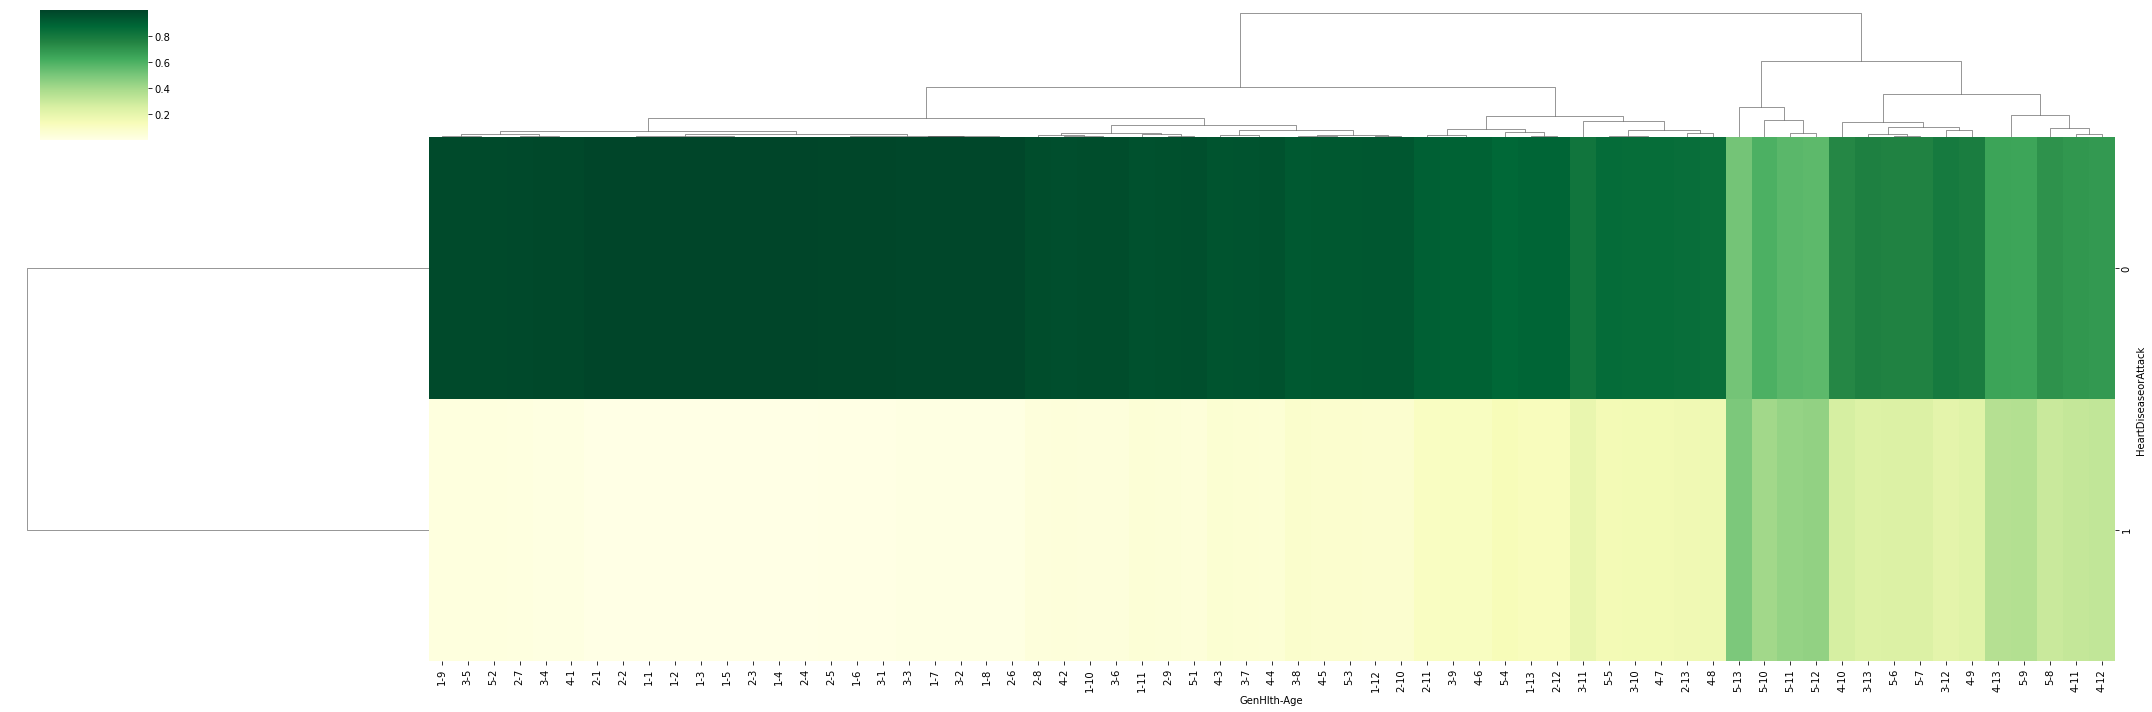

In [22]:
g = sns.clustermap(xs_vs_ys(df_xs,df_ys).T,cmap='YlGn',xticklabels=True,figsize=(30, 10))

In [23]:
#xs_vs_ys(df_xs,df_ys)

In [24]:
#clustering(g,df_xs,df_ys,dendo_plot=False,ids=True,figsize=(20, 20),fontsize=10)

In [25]:
x_subgroups=[(5,11),(5,12),(5,13)]
y_subgroups=[1]
cb_df = common_branch_df(df,
                         df_xs,
                         df_ys,
                         x_subgroups,
                         y_subgroups,
                         B=100)

In [26]:
#cb_df

In [27]:
commonality = cb_df["common_branch_length"] >= 2
mean_prob_y_x_og = np.mean(xs_vs_ys(df_xs,df_ys).loc[x_subgroups,y_subgroups]).iloc[0]
within_margin = [(i > mean_prob_y_x_og-0.05) & (i < mean_prob_y_x_og+0.05) for i in cb_df.loc[commonality,"mean_prob_y_x"]]
highest_risk = cb_df.loc[commonality,"mean_prob_y_x"] > cb_df.loc[commonality,"max_prob_y_not_x"]
print("Mean probability of heart disease with " +
      str(x_subgroups) +
      " is " +
      str(round(mean_prob_y_x_og,2)*100) +
      "%")
print(str(np.mean(commonality)*100) +
      " out of 100 samples show that " + 
      str(x_subgroups) + 
      " are as similar as they appear in our data")
print(str(np.mean([i & j for i,j in zip(within_margin,highest_risk)])*100) +
      "% of those samples also show that the cluster has highest risk of heart disease (at around " + 
      str(round(mean_prob_y_x_og,2)*100) +
      "%)")
print("Although it is the cluster with the highest risk, you are still less likely to have heart disease")

Mean probability of heart disease with [(5, 11), (5, 12), (5, 13)] is 45.0%
92.0 out of 100 samples show that [(5, 11), (5, 12), (5, 13)] are as similar as they appear in our data
100.0% of those samples also show that the cluster has highest risk of heart disease (at around 45.0%)
Although it is the cluster with the highest risk, you are still less likely to have heart disease


In our data, we see that seniors between the ages of (11_low) and (13_high) with the worst general health are quite notable. Namely, they are the cluster with the highest risk of heart disease, at around 45%. Now, our data also shows that seniors between the ages of (10_low) and (10_high) with the worst general health have a similar risk; however, we are excluding them from the aformentioned cluster due to its "unreliability". When regenerating 100 samples through the multinomial distribution, we see that people () are only as similar as they are in our data 73% of the time. Meanwhile, we see that people () are as similar as they are in our data 92% of the time, and all 92 samples support that this cluster has the highest risk, at around 45%. In other words, it is much more "reliable" to cluster and describe seniors between the ages of (11_low) and (13_high) with the worst general health. It is also worth noting that the risk of heart disease for this cluster is higher than those with the worst general health (34%) and seniors between the ages of (11_low) and (13_high) (20%). 

This specifically shows that having knowledge about one's general health and age can reveal drastic increases in risk and generally highlights the importance of studying interactions.

In [42]:
df_xs=[df["Stroke"],df["GenHlth"]]
df_ys=[df["HeartDiseaseorAttack"]]

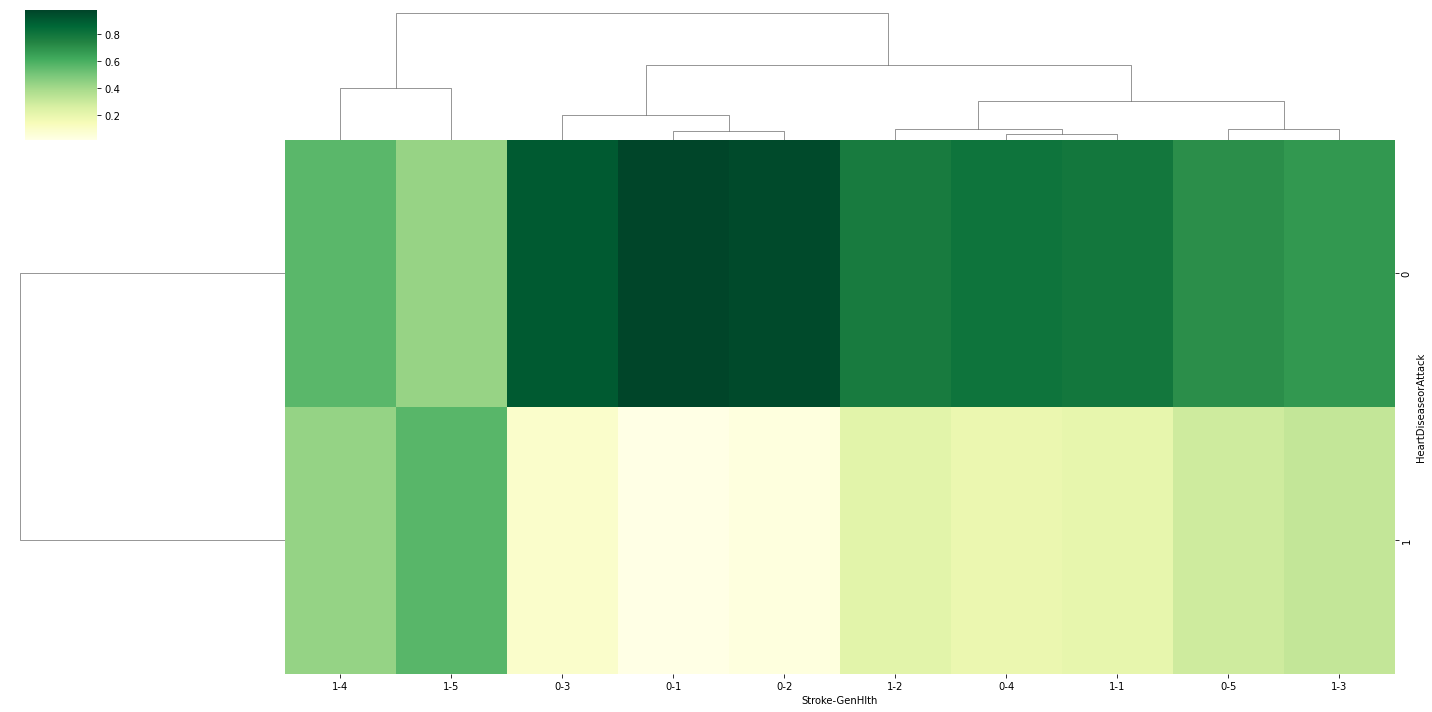

In [43]:
g = sns.clustermap(xs_vs_ys(df_xs,df_ys).T,cmap='YlGn',xticklabels=True,figsize=(20, 10))

In [55]:
#clustering(g,df_xs,df_ys,dendo_plot=False,ids=True,figsize=(20, 20),fontsize=10)

In [56]:
#xs_vs_ys(df_xs,df_ys)

In [47]:
x_subgroups=[(1,4),(1,5)]
y_subgroups=[1]
cb_df = common_branch_df(df,
                         df_xs,
                         df_ys,
                         x_subgroups,
                         y_subgroups,
                         B=100)

In [57]:
#cb_df

In [53]:
commonality = cb_df["common_branch_length"] >= 1
mean_prob_y_x_og = np.mean(xs_vs_ys(df_xs,df_ys).loc[x_subgroups,y_subgroups]).iloc[0]
within_margin = [(i > mean_prob_y_x_og-0.05) & (i < mean_prob_y_x_og+0.05) for i in cb_df.loc[commonality,"mean_prob_y_x"]]
highest_risk = cb_df.loc[commonality,"mean_prob_y_x"] > cb_df.loc[commonality,"max_prob_y_not_x"]
print("Mean probability of heart disease with " +
      str(x_subgroups) +
      " is " +
      str(round(mean_prob_y_x_og,2)*100) +
      "%")
print(str(np.mean(commonality)*100) +
      " out of 100 samples show that " + 
      str(x_subgroups) + 
      " are as similar as they appear in our data")
print(str(np.mean([i & j for i,j in zip(within_margin,highest_risk)])*100) +
      "% of those samples also show that the cluster has highest risk of heart disease (at around " + 
      str(round(mean_prob_y_x_og,2)*100) +
      "%)")
# Need to work on below
print("From 100 samples, " + 
      str((1, 5)) + 
      " has higher risk than any other subgroups 100% of the time")
print("From 100 samples, " + 
      str((1, 5)) + 
      " is the only subgroup who is more likely to have heart disease (at around 57.0%) 100% of the time")

Mean probability of heart disease with [(1, 4), (1, 5)] is 50.0%
98.0 out of 100 samples show that [(1, 4), (1, 5)] are as similar as they appear in our data
100.0% of those samples also show that the cluster has highest risk of heart disease (at around 50.0%)
From 100 samples, (1, 5) has higher risk than any other subgroups 100% of the time
From 100 samples, (1, 5) is the only subgroup who is more likely to have heart disease (at around 57.0%) 100% of the time


We also noticed interesting patterns with a two-way interaction between stroke and general health. Our data shows that those who have suffered a stroke and have poor general health have the highest risk of heart disease, at around 50%. In other words, the fate of this group (suffering severe chest pain) is ultimately decided by a flip of a coin. Like before, the reliability of these results is quite high. When regenerating 100 samples, we see that people () are as similar as they are in our data 98% of the time, and all 98 samples support that this cluster has the highest risk, at around 50%. Another interesting finding with this group is the subcluster held within itself, specifically those who have suffered a stroke and have the worst general health. Each one of our 100 samples show that this subcluster is the only one which is more likely to have heart disease, at around 57%. This is especially remarkable considering how much lower the risk is for those who have suffered a stroke (38%) and those with the worst general health (34%). 

Again, this illustrates the importance of examining interactions and the significant differences that occur when knowing about one's general health and stroke history. Moreover, the differences here are not only significant but completely life-altering. Namely, those who have suffered a stroke should avoid worsening their general health, and those with the worst general health should avoid activities that increase the risk of stroke- as doing otherwise would not only increase the risk of heart disease but make it more likely to occur.

In [78]:
GenHlth_Age_sig_x1_x2_x3_HD = sig_xs(df = df,
                                     B = 100,
                                     xs = ("GenHlth","Age"),
                                     df_ys = [df["HeartDiseaseorAttack"]],
                                     predictor_type = "three",
                                     sig_Info = 0)
GenHlth_Age_sig_x1_x2_x3_HD

,x1_x2_x3,Infos
0,"(GenHlth, Age, Sex)",0.061253
1,"(GenHlth, Age, HighChol)",0.060751
2,"(GenHlth, Age, HighBP)",0.060244
3,"(GenHlth, Age, Diabetes)",0.058151
4,"(GenHlth, Age, Income)",0.057995
5,"(GenHlth, Age, Smoker)",0.057876
6,"(GenHlth, Age, DiffWalk)",0.057292
7,"(GenHlth, Age, BMI_cat)",0.057164
8,"(GenHlth, Age, Education)",0.057116
9,"(GenHlth, Age, PhysHlth_cat)",0.056681


In [88]:
HighBP_GenHlth_sig_x1_x2_x3_HD = sig_xs(df = df,
                                        B = 100,
                                        xs = ("HighBP","GenHlth"),
                                        df_ys = [df["HeartDiseaseorAttack"]],
                                        predictor_type = "three",
                                        sig_Info = 0)
HighBP_GenHlth_sig_x1_x2_x3_HD

,x1_x2_x3,Infos
0,"(HighBP, GenHlth, Age)",0.060211
1,"(HighBP, GenHlth, Stroke)",0.048594
2,"(HighBP, GenHlth, HighChol)",0.048308
3,"(HighBP, GenHlth, Sex)",0.046861
4,"(HighBP, GenHlth, Diabetes)",0.045433
5,"(HighBP, GenHlth, Smoker)",0.045415
6,"(HighBP, GenHlth, DiffWalk)",0.044832
7,"(HighBP, GenHlth, Income)",0.044527
8,"(HighBP, GenHlth, MentHlth_cat)",0.044134
9,"(HighBP, GenHlth, Education)",0.043698


In [89]:
HighChol_GenHlth_sig_x1_x2_x3_HD = sig_xs(df = df,
                                          B = 100,
                                          xs = ("HighChol","GenHlth"),
                                          df_ys = [df["HeartDiseaseorAttack"]],
                                          predictor_type = "three",
                                          sig_Info = 0)
HighChol_GenHlth_sig_x1_x2_x3_HD

,x1_x2_x3,Infos
0,"(HighChol, GenHlth, Age)",0.060861
1,"(HighChol, GenHlth, HighBP)",0.048357
2,"(HighChol, GenHlth, Stroke)",0.047589
3,"(HighChol, GenHlth, Sex)",0.045645
4,"(HighChol, GenHlth, Diabetes)",0.044846
5,"(HighChol, GenHlth, DiffWalk)",0.043918
6,"(HighChol, GenHlth, Smoker)",0.043796
7,"(HighChol, GenHlth, Income)",0.043600
8,"(HighChol, GenHlth, MentHlth_cat)",0.042739
9,"(HighChol, GenHlth, Education)",0.042355


In [98]:
df_xs = [df["GenHlth"],df["Age"],df["Sex"]]
df_ys = [df["HeartDiseaseorAttack"]]

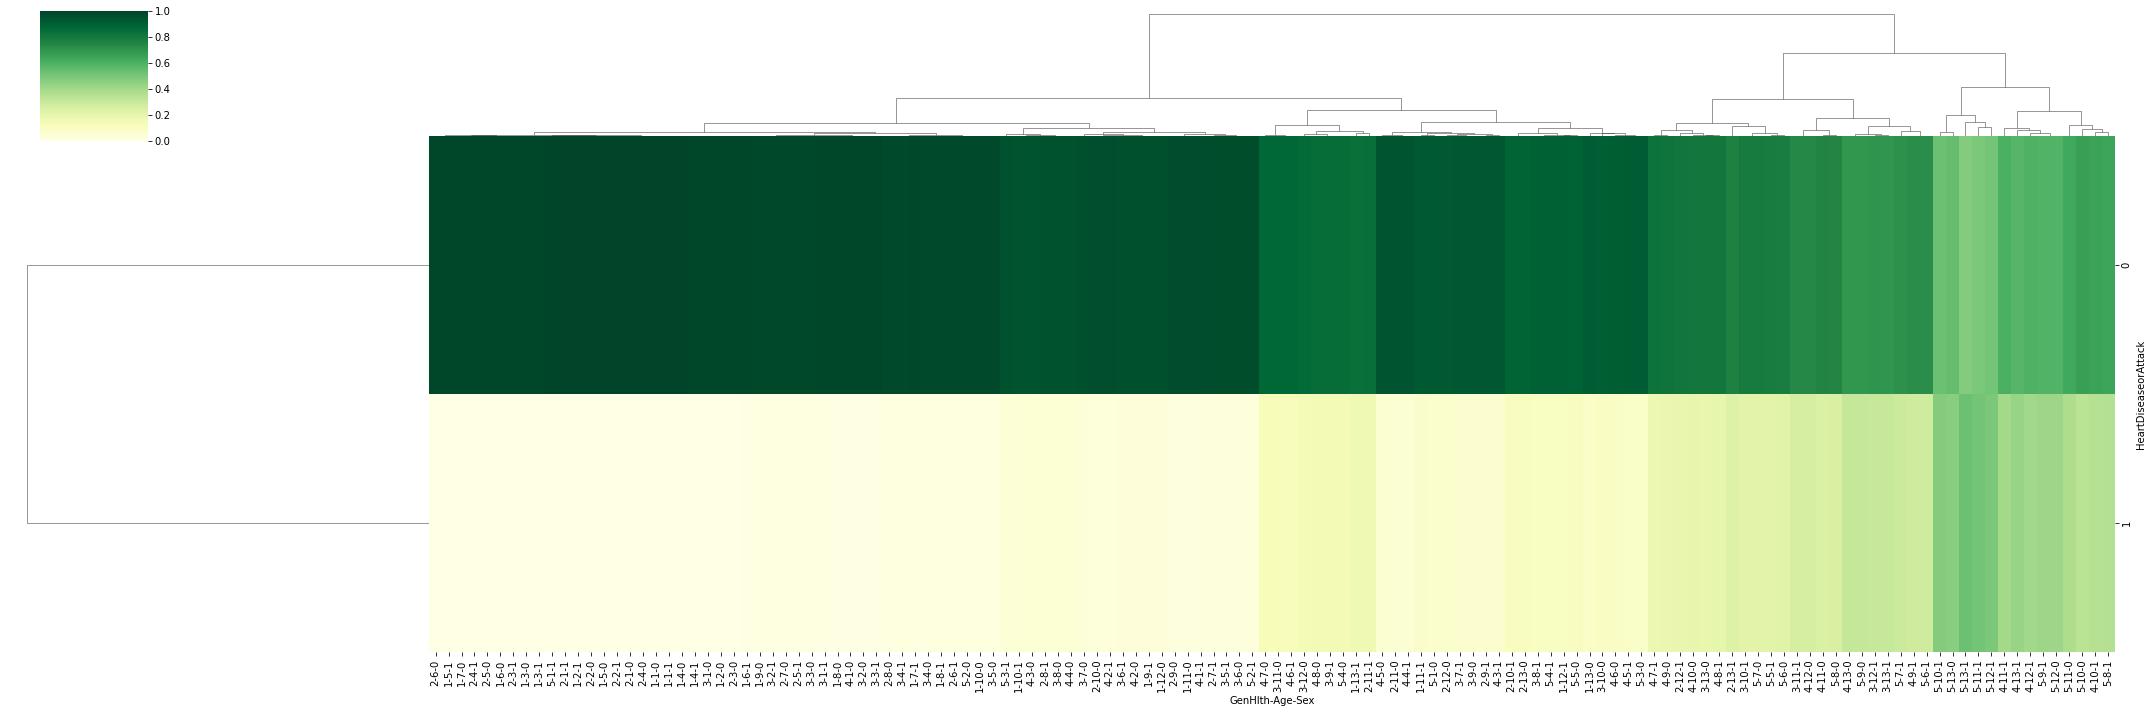

In [100]:
g = sns.clustermap(xs_vs_ys(df_xs,df_ys).T,cmap='YlGn',xticklabels=True,figsize=(30, 10))

In [152]:
xs_vs_ys([df["Sex"],df["GenHlth"],df["Age"]],[df["HeartDiseaseorAttack"]])

HeartDiseaseorAttack         0         1
Sex GenHlth Age                         
0   1       1         0.996727  0.003273
            2         0.995902  0.004098
            3         0.994471  0.005529
            4         0.996595  0.003405
            5         0.997633  0.002367
            6         0.994947  0.005053
            7         0.992603  0.007397
            8         0.989704  0.010296
            9         0.988228  0.011772
            10        0.980245  0.019755
            11        0.976067  0.023933
            12        0.964129  0.035871
            13        0.917782  0.082218
    2       1         0.997400  0.002600
            2         0.998130  0.001870
            3         0.995857  0.004143
            4         0.997332  0.002668
            5         0.994074  0.005926
            6         0.992798  0.007202
            7         0.987272  0.012728
            8         0.983193  0.016807
            9         0.974476  0.025524
            10        0.966608  0.033392
            11        0.940594  0.059406
            12        0.928620  0.071380
            13        0.889378  0.110622
    3       1         0.996042  0.003958
            2         0.990619  0.009381
            3         0.987554  0.012446
            4         0.984360  0.015640
            5         0.980138  0.019862
            6         0.970470  0.029530
            7         0.960418  0.039582
            8         0.950418  0.049582
            9         0.930233  0.069767
            10        0.905320  0.094680
            11        0.876897  0.123103
            12        0.859938  0.140062
            13        0.809769  0.190231
    4       1         0.989744  0.010256
            2         0.962838  0.037162
            3         0.949187  0.050813
            4         0.951183  0.048817
            5         0.937847  0.062153
            6         0.909458  0.090542
            7         0.873501  0.126499
            8         0.854561  0.145439
            9         0.821317  0.178683
            10        0.805778  0.194222
            11        0.752588  0.247412
            12        0.737154  0.262846
            13        0.690617  0.309383
    5       1         0.925926  0.074074
            2         0.979592  0.020408
            3         0.911765  0.088235
            4         0.853933  0.146067
            5         0.893238  0.106762
            6         0.783482  0.216518
            7         0.792669  0.207331
            8         0.748828  0.251172
            9         0.691033  0.308967
            10        0.662116  0.337884
            11        0.626761  0.373239
            12        0.589491  0.410509
            13        0.540323  0.459677
1   1       1         0.996503  0.003497
            2         0.997982  0.002018
            3         0.994359  0.005641
            4         0.995536  0.004464
            5         0.992563  0.007437
            6         0.988499  0.011501
            7         0.984885  0.015115
            8         0.981372  0.018628
            9         0.964495  0.035505
            10        0.948961  0.051039
            11        0.923756  0.076244
            12        0.895238  0.104762
            13        0.839752  0.160248
    2       1         0.998279  0.001721
            2         0.997243  0.002757
            3         0.994645  0.005355
            4         0.993922  0.006078
            5         0.987696  0.012304
            6         0.981499  0.018501
            7         0.972235  0.027765
            8         0.952483  0.047517
            9         0.935427  0.064573
            10        0.889024  0.110976
            11        0.846870  0.153130
            12        0.814438  0.185562
            13        0.766945  0.233055
    3       1         0.989233  0.010767
            2         0.988134  0.011866
            3         0.991336  0.008664
            4         0.983276  0.016724
            5         0

In [182]:
x_subgroups=[(5,10,1),(5,13,1),(5,11,1),(5,12,1)]
y_subgroups=[1]

In [183]:
clustering_df = clustering(g,df_xs,df_ys,dendo_plot=False,ids=True,figsize=(20, 20),fontsize=10)
clustering_df.loc[[i in x_subgroups for i in clustering_df["x_groups"]],:]

,x_groups,directional_ids
123,"(5, 10, 1)",11000
125,"(5, 11, 1)",110110
127,"(5, 12, 1)",110111
129,"(5, 13, 1)",11010


In [188]:
common_branch_length_og = 3

In [185]:
cb_df = common_branch_df(df,
                         df_xs,
                         df_ys,
                         x_subgroups,
                         y_subgroups,
                         B=100)

In [189]:
cb_df

,common_branch,common_branch_length,prob_y_x,mean_prob_y_x,max_prob_y_not_x
0,"[0, 1]",2,"[0.4705111402359109, 0.5327433628318584, 0.489...",0.494016,0.467877
1,"[1, 1]",2,"[0.44302176696542894, 0.5598591549295775, 0.47...",0.489048,0.479651
2,"[0, 1]",2,"[0.4849726775956284, 0.5601503759398496, 0.533...",0.524819,0.480272
3,[0],1,"[0.4664082687338501, 0.5321100917431193, 0.514...",0.501325,0.448133
4,"[0, 0]",2,"[0.5046854082998661, 0.5, 0.5045537340619308, ...",0.500588,0.496689
5,[0],1,"[0.4525065963060686, 0.5275735294117647, 0.499...",0.491038,0.473103
6,[0],1,"[0.4783748361730013, 0.5394736842105263, 0.532...",0.501100,0.464435
7,"[1, 1, 1]",3,"[0.5144429160935351, 0.5377176015473888, 0.470...",0.501843,0.470027
8,[0],1,"[0.45822454308093996, 0.5544747081712063, 0.50...",0.506521,0.466931
9,"[1, 1, 0]",3,"[0.48756218905472637, 0.5171102661596958, 0.49...",0.492679,0.455629


In [190]:
commonality = cb_df["common_branch_length"] >= common_branch_length_og
mean_prob_y_x_og = np.mean(xs_vs_ys(df_xs,df_ys).loc[x_subgroups,y_subgroups]).iloc[0]
within_margin = [(i > mean_prob_y_x_og-0.05) & (i < mean_prob_y_x_og+0.05) for i in cb_df.loc[commonality,"mean_prob_y_x"]]
highest_risk = cb_df.loc[commonality,"mean_prob_y_x"] > cb_df.loc[commonality,"max_prob_y_not_x"]
print("Mean probability of heart disease with " +
      str(x_subgroups) +
      " is " +
      str(round(mean_prob_y_x_og,2)*100) +
      "%")
print(str(np.mean(commonality)*100) +
      " out of 100 samples show that " + 
      str(x_subgroups) + 
      " are as similar as they appear in our data")
print(str(np.mean([i & j for i,j in zip(within_margin,highest_risk)])*100) +
      "% of those samples also show that the cluster has highest risk of heart disease (at around " + 
      str(round(mean_prob_y_x_og,2)*100) +
      "%)")

Mean probability of heart disease with [(5, 10, 1), (5, 13, 1), (5, 11, 1), (5, 12, 1)] is 50.0%
19.0 out of 100 samples show that [(5, 10, 1), (5, 13, 1), (5, 11, 1), (5, 12, 1)] are as similar as they appear in our data
94.73684210526315% of those samples also show that the cluster has highest risk of heart disease (at around 50.0%)


In [ ]:
# [(5,10,1),(5,13,0),(5,13,1),(5,11,1),(5,12,1)] 10%
# [(5,13,0),(5,13,1),(5,11,1),(5,12,1)] 13%
# [(5,10,1),(5,13,1),(5,11,1),(5,12,1)] 19%
# [(5,13,1),(5,11,1),(5,12,1)] 5%

When it comes to a three-way interaction between general health, age, and sex, there are several trends worth noting. Firstly, our data shows that male seniors between the ages of (10_low) and (13_high) with the worst general health have the highest risk of heart disease, at around 50%. And so, similar to those who have suffered a stroke and have poor general health, this group must rely on a coin toss in order to determine whether they (good fate) or (bad fate). Given the significant outcomes that this finding highlights, it is important to discuss its reliablity. Out of 100 regenerated samples, only 18 result in this group being in the same cluster and having the highest risk, at around 50%, as from our data. We are ultimately reporting this group due to its relatively higher consistency over other clusters. For instance, our data shows that female seniors between the ages of (13_low) and (13_high) with the worst general health share similar risks to the aforementioned group; however, only 13 out of 100 regenerated samples supported this finding. (Discuss why we might be seeing low consistency here or somewhere else). With this in mind, we must recall our findings for the two-way interaction between general health and age. As mentioned before, our data shows that the risk of heart disease for seniors between the ages of (11_low) and (13_high) with the worst general health is around 45%. When examining the three-way interaction between general health, age, and sex, we see that the risk is 50% for male seniors between ages of (10_low) and (13_high). Although each cluster summarizes different age ranges, both encapsulate the elderly and are thus comparable. And so, when setting these groups side by side, we see that being male not only increases the risk of heart disease for elder people with the worst general health but can nearly make it more likely to happen. This specifically illustrates how knowing one's sex in addition to their general health and age can provide more insight and make a significant difference.

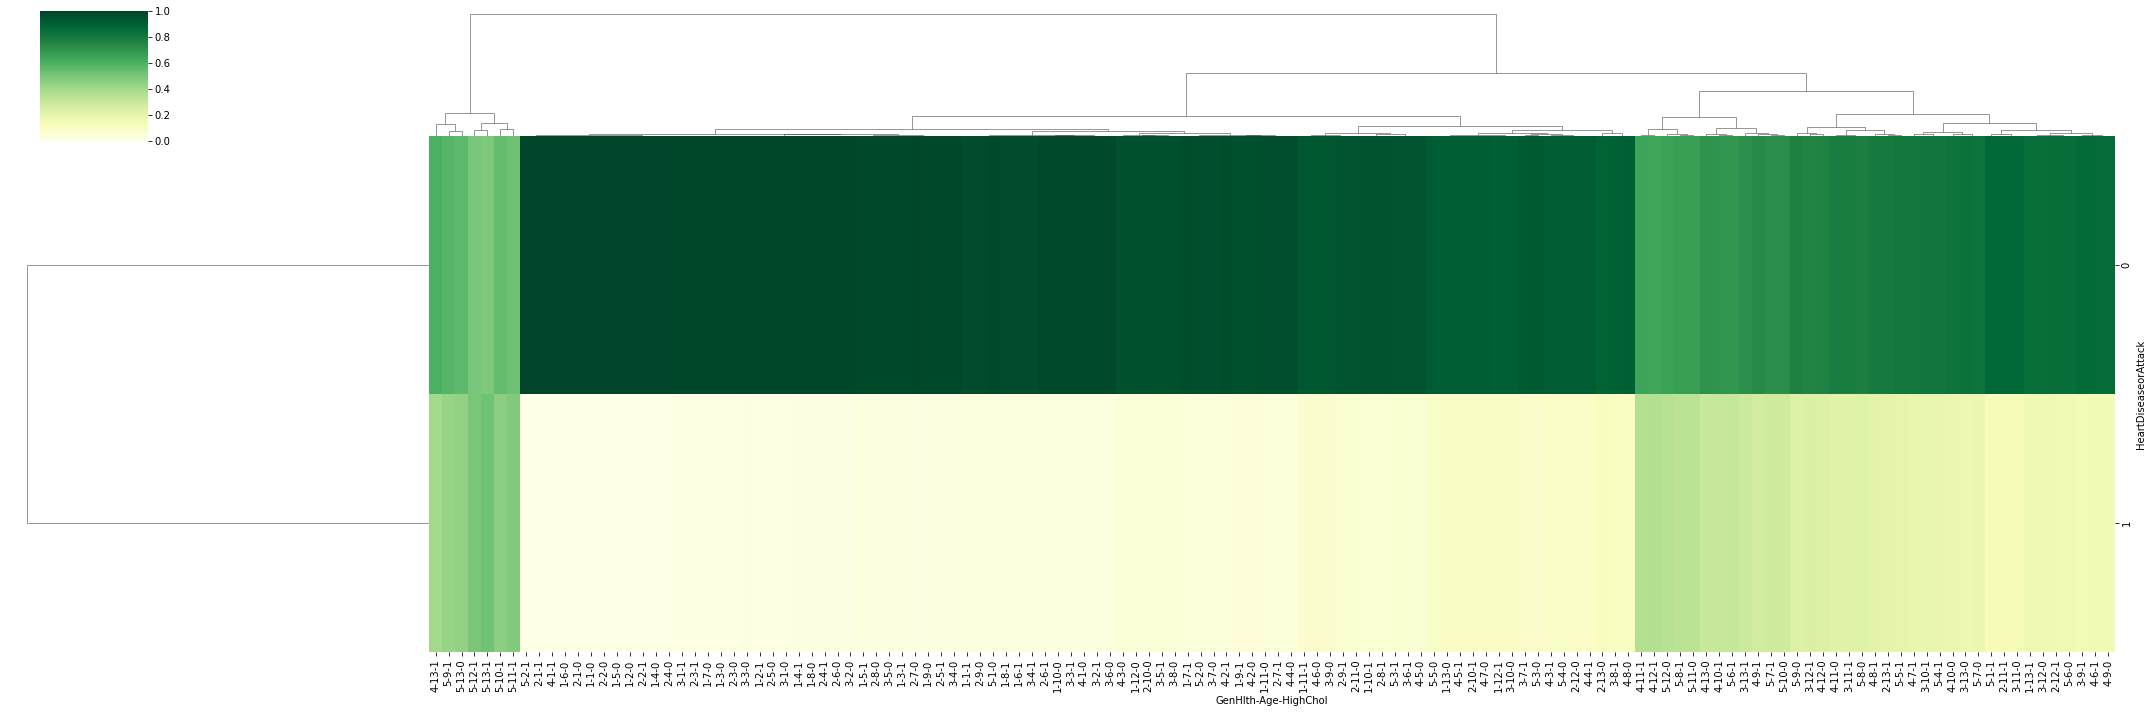

In [93]:
sns.clustermap(xs_vs_ys([df["GenHlth"],df["Age"],df["HighChol"]],[df["HeartDiseaseorAttack"]]).T,cmap='YlGn',xticklabels=True,figsize=(30, 10))

In [95]:
xs_vs_ys([df["HighChol"],df["GenHlth"],df["Age"]],[df["HeartDiseaseorAttack"]])

HeartDiseaseorAttack         0         1
HighChol GenHlth Age                    
0        1       1    0.997845  0.002155
                 2    0.997259  0.002741
                 3    0.995080  0.004920
                 4    0.997053  0.002947
                 5    0.997402  0.002598
                 6    0.996367  0.003633
                 7    0.994859  0.005141
                 8    0.990524  0.009476
                 9    0.985919  0.014081
                 10   0.978498  0.021502
                 11   0.966453  0.033547
                 12   0.959038  0.040962
                 13   0.909844  0.090156
         2       1    0.997636  0.002364
                 2    0.997774  0.002226
                 3    0.995253  0.004747
                 4    0.996850  0.003150
                 5    0.992690  0.007310
                 6    0.990995  0.009005
                 7    0.988298  0.011702
                 8    0.984574  0.015426
                 9    0.973380  0.026620
                 10   0.959699  0.040301
                 11   0.938479  0.061521
                 12   0.914583  0.085417
                 13   0.886864  0.113136
         3       1    0.992521  0.007479
                 2    0.990958  0.009042
                 3    0.992024  0.007976
                 4    0.986953  0.013047
                 5    0.984586  0.015414
                 6    0.981923  0.018077
                 7    0.968719  0.031281
                 8    0.957418  0.042582
                 9    0.936753  0.063247
                 10   0.905589  0.094411
                 11   0.870197  0.129803
                 12   0.847282  0.152718
                 13   0.828654  0.171346
         4       1    0.980707  0.019293
                 2    0.962779  0.037221
                 3    0.953982  0.046018
                 4    0.965181  0.034819
                 5    0.943489  0.056511
                 6    0.933590  0.066410
                 7    0.908828  0.091172
                 8    0.898524  0.101476
                 9    0.857061  0.142939
                 10   0.822122  0.177878
                 11   0.782723  0.217277
                 12   0.759239  0.240761
                 13   0.699623  0.300377
         5       1    0.976744  0.023256
                 2    0.968254  0.031746
                 3    0.923077  0.076923
                 4    0.913580  0.086420
                 5    0.911215  0.088785
                 6    0.849530  0.150470
                 7    0.827899  0.172101
                 8    0.776579  0.223421
                 9    0.767062  0.232938
                 10   0.721281  0.278719
                 11   0.661765  0.338235
                 12   0.655738  0.344262
                 13   0.562092  0.437908
1        1       1    0.974026  0.025974
                 2    0.993007  0.006993
                 3    0.987952  0.012048
                 4    0.989770  0.010230
                 5    0.984375  0.015625
                 6    0.975339  0.024661
                 7    0.970925  0.029075
                 8    0.975497  0.024503
                 9    0.962924  0.037076
                 10   0.948869  0.051131
                 11   0.933198  0.066802
                 12   0.903488  0.096512
                 13   0.846859  0.153141
         2       1    1.000000  0.000000
                 2    0.997214  0.002786
                 3    0.995562  0.004438
                 4    0.991194  0.008806
                 5    0.986486  0.013514
                 6    0.979239  0.020761
                 7    0.965278  0.034722
                 8    0.948477  0.051523
                 9    0.938840  0.061160
                 10   0.908544  0.091456
                 11   0.868590  0.131410
                 12   0.850694  0.149306
                 13   0.796837  0.203163
         3       1    0.993902  0.006098
                 2    0.982036  0.017964
                 3    0.978689  0.021311
                 4    0.975198  0.024802
                 5    0

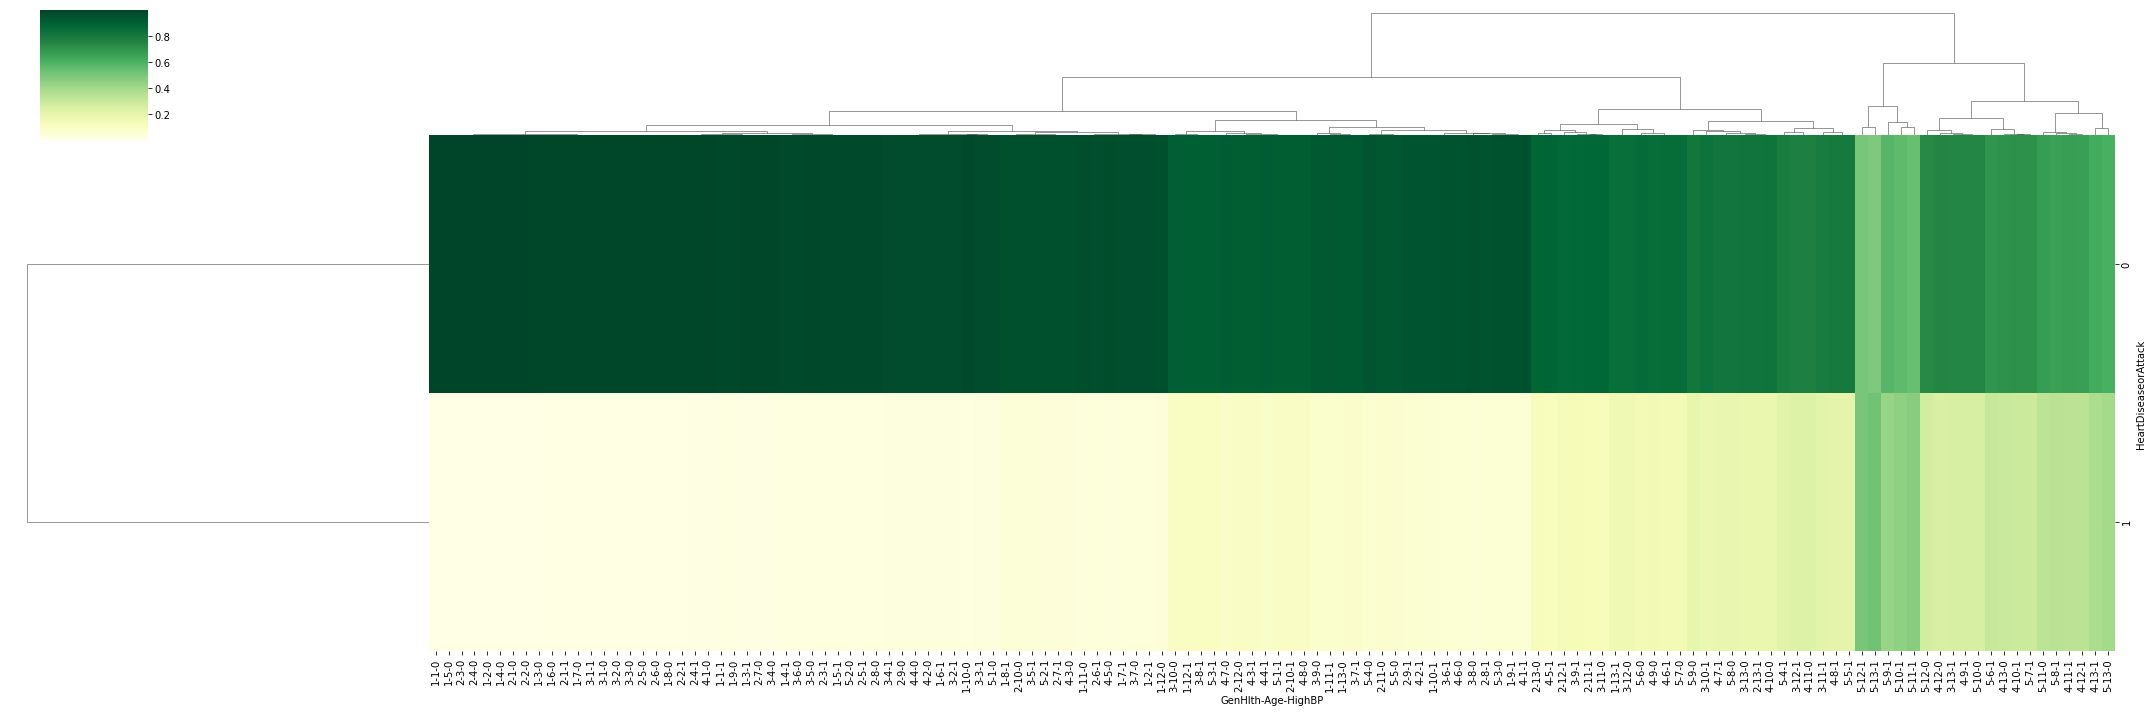

In [96]:
sns.clustermap(xs_vs_ys([df["GenHlth"],df["Age"],df["HighBP"]],[df["HeartDiseaseorAttack"]]).T,cmap='YlGn',xticklabels=True,figsize=(30, 10))

In [97]:
xs_vs_ys([df["HighBP"],df["GenHlth"],df["Age"]],[df["HeartDiseaseorAttack"]])

HeartDiseaseorAttack         0         1
HighBP GenHlth Age                      
0      1       1      0.997128  0.002872
               2      0.998922  0.001078
               3      0.994847  0.005153
               4      0.997555  0.002445
               5      0.996667  0.003333
               6      0.994556  0.005444
               7      0.993672  0.006328
               8      0.992979  0.007021
               9      0.986842  0.013158
               10     0.977157  0.022843
               11     0.968807  0.031193
               12     0.963262  0.036738
               13     0.923391  0.076609
       2       1      0.998126  0.001874
               2      0.998193  0.001807
               3      0.996953  0.003047
               4      0.996814  0.003186
               5      0.993178  0.006822
               6      0.993202  0.006798
               7      0.987964  0.012036
               8      0.981721  0.018279
               9      0.971812  0.028188
               10     0.957326  0.042674
               11     0.935607  0.064393
               12     0.906358  0.093642
               13     0.879845  0.120155
       3       1      0.992537  0.007463
               2      0.992784  0.007216
               3      0.992881  0.007119
               4      0.988049  0.011951
               5      0.983881  0.016119
               6      0.980742  0.019258
               7      0.965153  0.034847
               8      0.954120  0.045880
               9      0.928448  0.071552
               10     0.902151  0.097849
               11     0.874567  0.125433
               12     0.839352  0.160648
               13     0.817080  0.182920
       4       1      0.990033  0.009967
               2      0.973190  0.026810
               3      0.961111  0.038889
               4      0.971810  0.028190
               5      0.967908  0.032092
               6      0.944724  0.055276
               7      0.913944  0.086056
               8      0.908206  0.091794
               9      0.850399  0.149601
               10     0.819686  0.180314
               11     0.771131  0.228869
               12     0.749091  0.250909
               13     0.705314  0.294686
       5       1      0.975000  0.025000
               2      0.982759  0.017241
               3      0.948980  0.051020
               4      0.939024  0.060976
               5      0.936508  0.063492
               6      0.857143  0.142857
               7      0.851429  0.148571
               8      0.813996  0.186004
               9      0.806510  0.193490
               10     0.744304  0.255696
               11     0.670068  0.329932
               12     0.732794  0.267206
               13     0.605863  0.394137
1      1       1      0.986842  0.013158
               2      0.963964  0.036036
               3      0.987879  0.012121
               4      0.979424  0.020576
               5      0.982818  0.017182
               6      0.972727  0.027273
               7      0.965699  0.034301
               8      0.958494  0.041506
               9      0.950626  0.049374
               10     0.943890  0.056110
               11     0.925508  0.074492
               12     0.898501  0.101499
               13     0.839450  0.160550
       2       1      0.994505  0.005495
               2      0.993056  0.006944
               3      0.983019  0.016981
               4      0.989460  0.010540
               5      0.982293  0.017707
               6      0.967554  0.032446
               7      0.961855  0.038145
               8      0.948038  0.051962
               9      0.937294  0.062706
               10     0.908358  0.091642
               11     0.872488  0.127512
               12     0.864327  0.135673
               13     0.818511  0.181489
       3       1      0.993789  0.006211
               2      0.972727  0.027273
               3      0.975166  0.024834
               4      0.971972  0.028028
               5      0

In [90]:
# Interesting ?
    #xs_vs_ys([df["HvyAlcoholConsump"]],[df["HeartDiseaseorAttack"]])
    #xs_vs_ys([df["HvyAlcoholConsump"]],[df["Age"]])
# Interesting ?
    #xs_vs_ys([df["AnyHealthcare"]],[df["HeartDiseaseorAttack"]])
    #xs_vs_ys([df["AnyHealthcare"]],[df["GenHlth"]])

In [40]:
sig_xs_HD_Stoke = sig_xs(df = df,
                         B = 100,
                         xs = df.columns.drop(["HeartDiseaseorAttack","Stroke"]),
                         df_ys = [df["HeartDiseaseorAttack"],df["Stroke"]],
                         predictor_type = "one",
                         sig_Info = 0)
sig_xs_HD_Stoke

,xs,Infos
0,GenHlth,0.040668
1,Age,0.034098
2,HighBP,0.026936
3,DiffWalk,0.025083
4,PhysHlth_cat,0.018397
5,HighChol,0.018318
6,Diabetes,0.015460
7,Income,0.014932
8,Smoker,0.007229
9,Education,0.006288


In [41]:
sig_x1_x2_HD_Stoke = sig_xs(df = df,
                            B = 100,
                            xs = df.columns.drop(["HeartDiseaseorAttack","Stroke"]),
                            df_ys = [df["HeartDiseaseorAttack"],df["Stroke"]],
                            predictor_type = "two",
                            sig_Info = 0.040668)
sig_x1_x2_HD_Stoke

,x1_x2,Infos
0,"(GenHlth, Age)",0.069978
1,"(HighBP, GenHlth)",0.054159
2,"(DiffWalk, Age)",0.052749
3,"(Age, PhysHlth_cat)",0.051834
4,"(HighChol, GenHlth)",0.051208
5,"(HighBP, Age)",0.047856
6,"(Age, Income)",0.047276
7,"(GenHlth, DiffWalk)",0.046348
8,"(Diabetes, GenHlth)",0.045946
9,"(GenHlth, Sex)",0.044879


In [192]:
df_xs=[df["GenHlth"],df["Age"]]
df_ys=[df["HeartDiseaseorAttack"],df["Stroke"]]

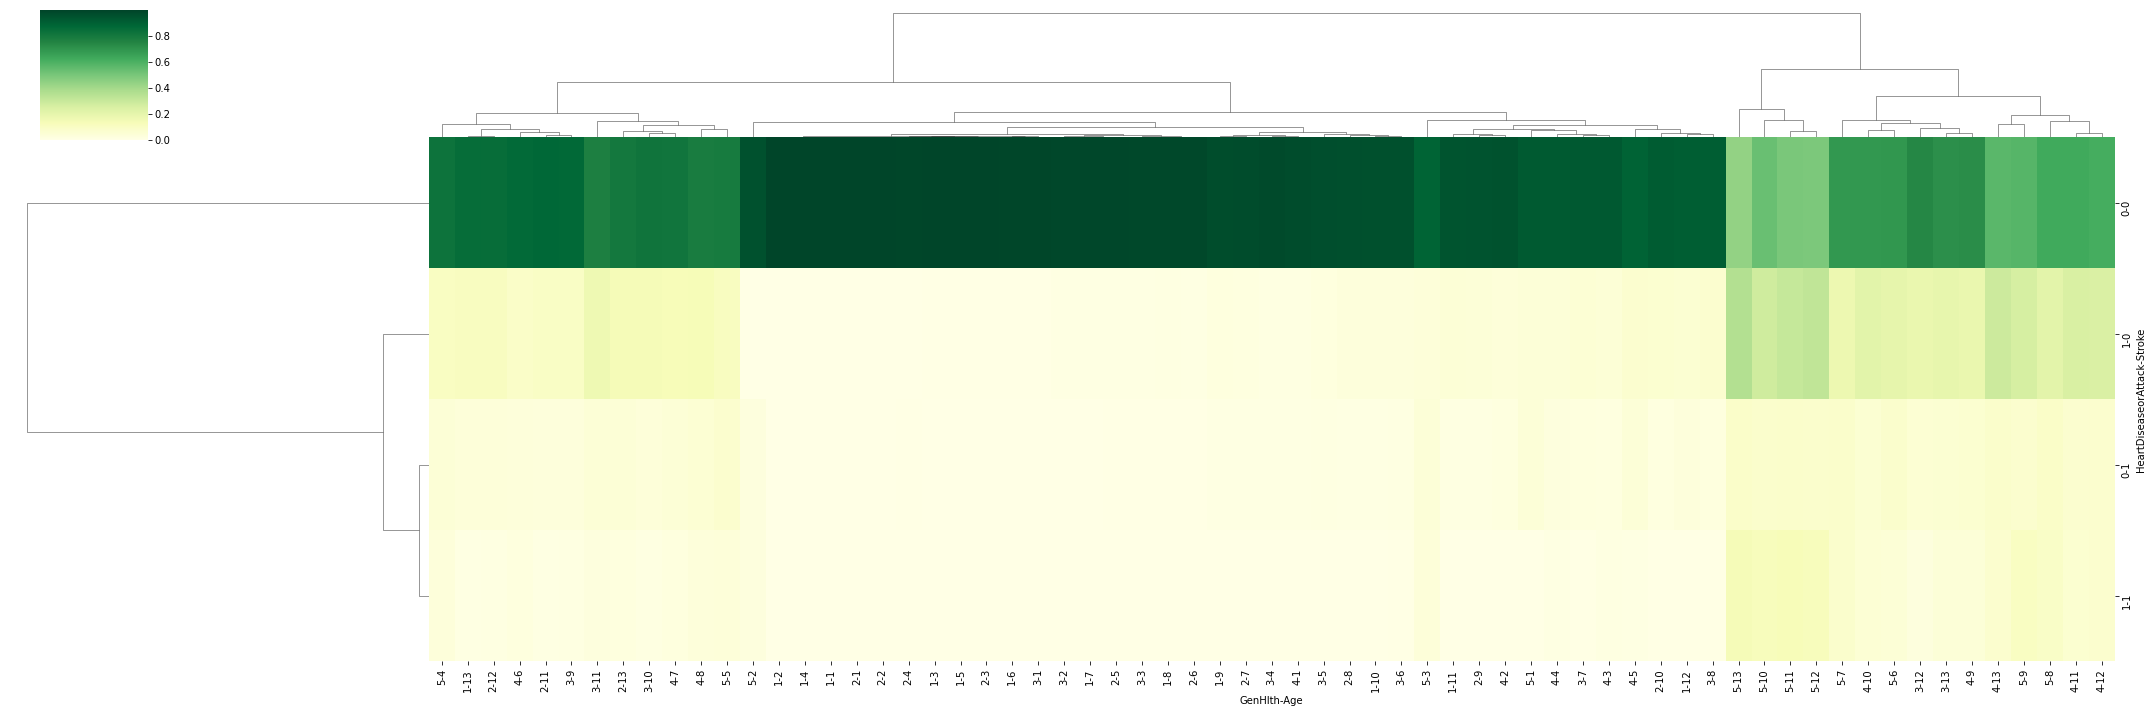

In [193]:
g = sns.clustermap(xs_vs_ys(df_xs,df_ys).T,cmap='YlGn',xticklabels=True,figsize=(30, 10))

In [249]:
xs_vs_ys(df_xs,df_ys)

HeartDiseaseorAttack         0                   1          
Stroke                       0         1         0         1
GenHlth Age                                                 
1       1             0.995235  0.001361  0.002723  0.000681
        2             0.996441  0.000508  0.002034  0.001017
        3             0.992560  0.001860  0.004464  0.001116
        4             0.993883  0.002254  0.002898  0.000966
        5             0.993038  0.002506  0.004456  0.000000
        6             0.989548  0.002674  0.007292  0.000486
        7             0.985871  0.003582  0.008557  0.001990
        8             0.981352  0.004897  0.012808  0.000942
        9             0.968936  0.009030  0.021131  0.000903
        10            0.955922  0.010874  0.029515  0.003689
        11            0.939014  0.013394  0.045882  0.001710
        12            0.906203  0.028744  0.057489  0.007564
        13            0.848730  0.035116  0.105348  0.010805
2       1             0.995682  0.002159  0.002159  0.000000
        2             0.995417  0.002291  0.001964  0.000327
        3             0.992838  0.002462  0.004700  0.000000
        4             0.991403  0.004390  0.003841  0.000366
        5             0.985967  0.005283  0.008420  0.000330
        6             0.981069  0.006591  0.011359  0.000982
        7             0.972213  0.008261  0.018024  0.001502
        8             0.960448  0.009422  0.027519  0.002612
        9             0.944702  0.012444  0.040312  0.002541
        10            0.914570  0.017731  0.062058  0.005642
        11            0.869907  0.029826  0.092271  0.007996
        12            0.844952  0.036458  0.106571  0.012019
        13            0.798431  0.044902  0.136078  0.020588
3       1             0.990673  0.001999  0.005330  0.001999
        2             0.987958  0.001505  0.009533  0.001004
        3             0.982620  0.006684  0.008690  0.002005
        4             0.975806  0.008065  0.014568  0.001561
        5             0.963133  0.012435  0.021815  0.002618
        6             0.954011  0.012989  0.028436  0.004564
        7             0.926204  0.020663  0.047766  0.005367
        8             0.904996  0.021521  0.065789  0.007694
        9             0.864876  0.029313  0.093045  0.012767
        10            0.816268  0.036072  0.132536  0.015124
        11            0.768995  0.044921  0.160757  0.025327
        12            0.737658  0.054414  0.181441  0.026486
        13            0.709106  0.056642  0.193150  0.041103
4       1             0.972452  0.011019  0.013774  0.002755
        2             0.946000  0.018000  0.036000  0.000000
        3             0.924411  0.018587  0.044610  0.012392
        4             0.920536  0.026786  0.041964  0.010714
        5             0.888516  0.039624  0.063130  0.008731
        6             0.862588  0.032941  0.083765  0.020706
        7             0.810714  0.043182  0.125000  0.021104
        8             0.781421  0.053403  0.130154  0.035022
        9             0.718039  0.058888  0.182137  0.040937
        10            0.682022  0.055955  0.211910  0.050112
        11            0.624633  0.064374  0.250147  0.060847
        12            0.614361  0.067769  0.248084  0.069786
        13            0.567858  0.076558  0.285669  0.069915
5       1             0.921569  0.039216  0.039216  0.000000
        2             0.951807  0.024096  0.000000  0.024096
        3             0.886905  0.041667  0.035714  0.035714
        4             0.825175  0.045455  0.097902  0.031469
        5             0.788991  0.066514  0.107798  0.036697
        6             0.687500  0.070479  0.196809  0.045213
        7             0.684321  0.075958  0.168641  0.071080
        8             0.622996  0.082366  0.207297  0.087341
        9             0.575116  0.067630  0.259680  0.097574
        10            0.530774  0.070079  0.279707  0.119439
        11            0.490733  0.0

In [256]:
x_subgroups=[(5,11),(5,12),(5,13)]
y_subgroups=[(0,1)]

In [257]:
clustering_df = clustering(g,df_xs,df_ys,dendo_plot=False,ids=True,figsize=(20, 20),fontsize=10)
clustering_df.loc[[i in x_subgroups for i in clustering_df["x_groups"]],:]

,x_groups,directional_ids
62,"(5, 11)",10110
63,"(5, 12)",10111
64,"(5, 13)",100


In [258]:
common_branch_length_og = 2

In [259]:
cb_df = common_branch_df(df,
                         df_xs,
                         df_ys,
                         x_subgroups,
                         y_subgroups,
                         B=100)

In [260]:
cb_df

,common_branch,common_branch_length,prob_y_x,mean_prob_y_x,max_prob_y_not_x
0,"[1, 0]",2,"[0.07472712006717044, 0.06878306878306878, 0.0...",0.073069,0.085476
1,"[1, 1]",2,"[0.08326848249027237, 0.06950207468879668, 0.0...",0.081734,0.084459
2,"[1, 0]",2,"[0.07392363931762795, 0.07177974434611603, 0.0...",0.071491,0.091922
3,"[1, 0]",2,"[0.07757885763000852, 0.06653225806451613, 0.0...",0.074201,0.087389
4,"[1, 0, 1]",3,"[0.06850459482038429, 0.08040201005025126, 0.0...",0.073004,0.089226
5,"[1, 1, 0]",3,"[0.06923076923076923, 0.0707876370887338, 0.07...",0.070388,0.080447
6,"[1, 0]",2,"[0.0631911532385466, 0.06504065040650407, 0.06...",0.065732,0.083693
7,"[0, 0]",2,"[0.0862207896857373, 0.06960081883316274, 0.06...",0.074499,0.087605
8,"[0, 1]",2,"[0.08092485549132948, 0.06172839506172839, 0.0...",0.074834,0.086659
9,[0],1,"[0.06351791530944625, 0.06634615384615385, 0.0...",0.066748,0.082739


In [261]:
commonality = cb_df["common_branch_length"] >= common_branch_length_og
mean_prob_y_x_og = np.mean(xs_vs_ys(df_xs,df_ys).loc[x_subgroups,y_subgroups]).iloc[0]
within_margin = [(i > mean_prob_y_x_og-0.05) & (i < mean_prob_y_x_og+0.05) for i in cb_df.loc[commonality,"mean_prob_y_x"]]
highest_risk = cb_df.loc[commonality,"mean_prob_y_x"] > cb_df.loc[commonality,"max_prob_y_not_x"]
print("Mean probability of " +
      str(y_subgroups) +
      " with " +
      str(x_subgroups) +
      " is " +
      str(round(mean_prob_y_x_og,2)*100) +
      "%")
print(str(np.mean(commonality)*100) +
      " out of 100 samples show that " + 
      str(x_subgroups) + 
      " are as similar as they appear in our data")
print(str(np.mean([i & j for i,j in zip(within_margin,highest_risk)])*100) +
      "% of those samples also show that the cluster has highest risk of " +
      str(y_subgroups) + 
      " (at around " + 
      str(round(mean_prob_y_x_og,2)*100) +
      "%)")

Mean probability of [(0, 1)] with [(5, 11), (5, 12), (5, 13)] is 8.0%
89.0 out of 100 samples show that [(5, 11), (5, 12), (5, 13)] are as similar as they appear in our data
10.112359550561797% of those samples also show that the cluster has highest risk of [(0, 1)] (at around 8.0%)


In [ ]:
# [(0,1)]
    # [(3,12),(3,13),(4,9),(4,10),(4,11),(4,12),(4,13),(5,6),(5,7),(5,8),(5,9),(5,10),(5,11),(5,12),(5,13)] 7% with 58% * 50% reliability
    # [(5, 7), (5, 8), (5, 9), (5, 10), (5, 11), (5, 12), (5, 13)] is 7% with 70% * 17% reliability
    # [(5, 10), (5, 11), (5, 12), (5, 13)] is 7% with 63% * 3% reliability
    # [[]]
# [(1,0)]
    # [(5, 10),(5, 11), (5, 12), (5, 13)] is 32% with 63% reliability
    # [(5, 11), (5, 12), (5, 13)] is 33% with 89% reliability
# [(1,1)]
    # [(5, 10),(5, 11), (5, 12), (5, 13)] is 12% with 63% reliability
    # [(5, 11), (5, 12), (5, 13)] is 13% with 89% * 72% reliability

The reason why HD risk is higher for men may be because smoking significantly increase HD risk and men are more likely to be smokers

The reason why Stroke risk is higher for women may be because of pregnancy and birth-control. 

During pregnancy, levels of estrogen and progesterone increase, which can cause changes in the walls of blood vessels and lead to an increased risk of blood clots. Pregnancy can also cause an increase in blood volume and blood pressure, which can put additional strain on blood vessels and increase the risk of stroke. In addition, certain medical conditions that can occur during pregnancy, such as preeclampsia, gestational diabetes, and blood clotting disorders, can also increase the risk of stroke. 

Birth control pills contain estrogen and progesterone hormones that can increase the risk of blood clots in the body. These hormones can cause changes in the blood that make it more likely to clot, which can increase the risk of stroke. Additionally, birth control pills can cause changes in the blood vessels that make them more prone to injury and more likely to form clots.

In [ ]:
# https://www.cdc.gov/nchs/nsfg/key_statistics/b.htm
# https://news.sanfordhealth.org/womens/medications-for-high-blood-pressure-during-pregnancy/
# https://www.uab.edu/news/research/item/6102-blood-pressure-medications-can-lead-to-increased-risk-of-stroke-study-finds
# https://www.ncbi.nlm.nih.gov/pmc/articles/PMC8102467/

In [ ]:
df_HD_Stroke_00 = df.loc[(df["HeartDiseaseorAttack"]==0)&(df["Stroke"]==0),:]
df_HD_Stroke_01 = df.loc[(df["HeartDiseaseorAttack"]==0)&(df["Stroke"]==1),:]
df_HD_Stroke_10 = df.loc[(df["HeartDiseaseorAttack"]==1)&(df["Stroke"]==0),:]
df_HD_Stroke_11 = df.loc[(df["HeartDiseaseorAttack"]==1)&(df["Stroke"]==1),:]
from sklearn.utils import resample
df_HD_Stroke_00_balance = resample(df_HD_Stroke_00,replace=True,n_samples=62500,random_state=24) 
df_HD_Stroke_01_balance = resample(df_HD_Stroke_01,replace=True,n_samples=62500,random_state=24) 
df_HD_Stroke_10_balance = resample(df_HD_Stroke_10,replace=True,n_samples=62500,random_state=24) 
df_HD_Stroke_11_balance = resample(df_HD_Stroke_11,replace=True,n_samples=62500,random_state=24) 
df_balance = pd.concat([df_HD_Stroke_00_balance,
                        df_HD_Stroke_01_balance,
                        df_HD_Stroke_10_balance,
                        df_HD_Stroke_11_balance]).reset_index(drop=True)
df_train = resample(df_balance,replace=False,n_samples=200000,random_state=24)
df_test = df_balance.drop(df_train.index)